 
**Stack:** T-SQL · Python · pandas · matplotlib  
**Source:** Northwind Database (SQL Server 2022)



## Executive Summary

This analysis answers six business questions across three operational domains using Northwind transaction and fulfillment data:

1. **Which suppliers drive the most revenue?**
2. **How does each supplier rank within their product category?**
3. **How has monthly revenue trended?**
4. **What is the month-over-month growth rate and 3-month rolling average?**
5. **Are orders being shipped on time?**
6. **Which shippers have the longest delays? Which employees handle the most volume?**

**Key findings:**





## Business Context

Northwind is a fictional wholesale food distributor. Understanding supplier revenue contribution helps procurement teams prioritize vendor relationships, negotiate contracts, and identify concentration 
risk, where revenue depends heavily on a small number of suppliers.


## Section 1: Supplier Revenue Analysis

### Business Questions
1. Which suppliers drive the most revenue?
2. How does each supplier rank within their product category?

### Context

For a wholesale distributor like Northwind, supplier relationships are the foundation of the business. Not all suppliers contribute equally, a small number typically drive the majority of revenue, while others serve niche product categories with lower overall volume.

Understanding supplier revenue concentration helps procurement teams:

- **Prioritize** vendor relationships and contract negotiations
- **Identify** dependency risk where revenue relies on few suppliers
- **Compare** supplier performance within the same product category, a supplier may rank low overall but dominate their category

### Data Model

This analysis joins three tables:

| Table | Role |
|---|---|
| `Suppliers` | Vendor identity: SupplierID, CompanyName |
| `Products` | Catalog: links suppliers to categories |
| `Order Details` | Line-item transactions: quantity, unit price, discount |
| `Categories` | Category names: Beverages, Dairy, Seafood, etc. |

### Revenue Formula

Revenue is calculated at the line-item level:
__net_revenue = unit_price × quantity × (1 - discount)__

Discount is captured separately to show both the gross revenue 
potential and the actual net revenue per supplier after markdowns.

---

### Query Design

The query uses a **3-CTE pattern**  each step has a single 
responsibility, making the logic easier to read, debug, and extend.

| CTE | Responsibility |
|---|---|
| `SupplierProducts` | Resolves supplier → product → category relationships |
| `SupplierOrders` | Flattens to order line items with pricing |
| `SupplierTotals` | Aggregates revenue, quantity, and discount per supplier |

Two window functions are applied on the aggregated results:

- `RANK() OVER (ORDER BY total_order_revenue DESC)`  overall rank across all suppliers
- `RANK() OVER (PARTITION BY CategoryName ORDER BY total_order_revenue DESC)` rank within each product category

The `PARTITION BY CategoryName` is the key analytical addition it resets the rank for each category independently, allowing direct 
comparison of suppliers competing in the same product segment.

In [ ]:
WITH MonthlySales AS (
    SELECT
        DATEFROMPARTS(YEAR(o.OrderDate), MONTH(o.OrderDate), 1) AS SaleMonth,
        SUM(od.UnitPrice * od.Quantity * (1 - od.Discount))     AS MonthlyRevenue
    FROM Orders o
    JOIN [Order Details] od ON o.OrderID = od.OrderID
    WHERE o.OrderDate IS NOT NULL
    GROUP BY DATEFROMPARTS(YEAR(o.OrderDate), MONTH(o.OrderDate), 1)
)
SELECT
    SaleMonth,
    ROUND(MonthlyRevenue, 2)                                          AS MonthlyRevenue,
    ROUND(LAG(MonthlyRevenue, 1) OVER (ORDER BY SaleMonth), 2)       AS PriorMonthRevenue,
    ROUND(
        (MonthlyRevenue - LAG(MonthlyRevenue, 1) OVER (ORDER BY SaleMonth))
        / NULLIF(LAG(MonthlyRevenue, 1) OVER (ORDER BY SaleMonth), 0) * 100
    , 1)                                                              AS MoMGrowthPct,
    ROUND(
        AVG(MonthlyRevenue) OVER (
            ORDER BY SaleMonth
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        )
    , 2)                                                              AS Rolling3MonthAvg
FROM MonthlySales
ORDER BY SaleMonth;

In [9]:
#Load libraries
import os
from pathlib import Path
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Establish Database Connection
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=Northwind;"
    "Trusted_Connection=yes;"
)

# Import supplier_ranking query from SQL files in dir
supplier_ranking_query = Path("01_supplier_ranking.sql").read_text()
supplier_ranking = pd.read_sql(supplier_ranking_query, conn)
conn.close()

C:\Users\chris\AppData\Local\Temp\ipykernel_53180\1451001728.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  supplier_ranking = pd.read_sql(supplier_ranking_query, conn)


### Visualizations

#### Top 15 Suppliers by Revenue

The chart below ranks the top 15 suppliers by total net revenue. 
Bars are colored by product category — revealing which categories 
dominate the top revenue positions and where supplier concentration 
is highest.

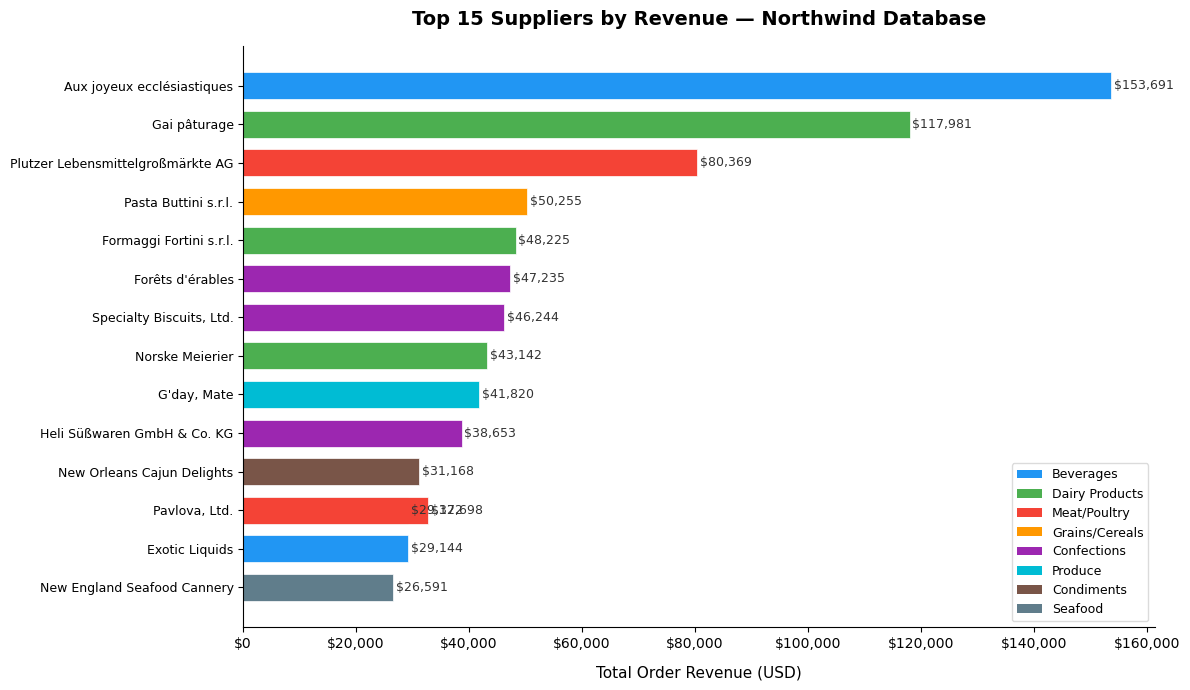

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

# Take top 15 by revenue rank
top15 = supplier_ranking.head(15).sort_values("total_order_revenue", ascending=True)

# Color bars by category
categories = top15["CategoryName"].unique()
color_map = {
    "Beverages":      "#2196F3",
    "Dairy Products": "#4CAF50",
    "Meat/Poultry":   "#F44336",
    "Grains/Cereals": "#FF9800",
    "Confections":    "#9C27B0",
    "Produce":        "#00BCD4",
    "Condiments":     "#795548",
    "Seafood":        "#607D8B",
}
colors = top15["CategoryName"].map(color_map)

bars = ax.barh(
    top15["SupplierName"],
    top15["total_order_revenue"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
    height=0.7
)

# Revenue labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333"
    )

# Formatting
ax.set_xlabel("Total Order Revenue (USD)", fontsize=11, labelpad=10)
ax.set_title("Top 15 Suppliers by Revenue — Northwind Database", fontsize=14, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

# Legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cat], label=cat) for cat in color_map if cat in top15["CategoryName"].values]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.7)

plt.tight_layout()
plt.show()